# Reading Keysight HDF5 oscilloscope files

This notebook shows the intended use of `lab_tools.io.read_keysight_h5` for Keysight oscilloscope waveform files.

The reader returns three objects:

- `time`: the sample time axis, usually one-dimensional for relative-time overlay plots
- `voltage`: a two-dimensional array with shape `(n_waveforms, n_samples)`
- `metadata`: file, channel, and segment metadata from the HDF5 file


## Imports

This notebook assumes `Lab-tools` is installed in the active Python/Jupyter
environment. See the main `README.md` for setup instructions.

In [1]:
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lab_tools.io import read_keysight_h5, read_segment_time_tags


## Example file

`examples/data/run530_5waveforms.h5` is a small example file with two channels.

In [2]:
data_file = Path("data/run530_5waveforms.h5")

if not data_file.exists():
    raise FileNotFoundError(f"Could not find {data_file}. Run this notebook from the examples directory.")

print(f"Using data file: {data_file.resolve()}")


Using data file: /Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/Lab-tools/examples/data/run530_5waveforms.h5


## File structure

Keysight oscilloscope HDF5 files store waveforms under `/Waveforms`. Each oscilloscope channel is a group, such as `/Waveforms/Channel 1` or `/Waveforms/Channel 2`.

A segmented acquisition stores many repeated waveforms from the same channel. Each repeated waveform is called a segment. In this example file, Channel 1 contains datasets named `Channel 1 Seg1Data`, `Channel 1 Seg2Data`, and so on.

Each segment dataset contains raw integer samples. The channel attributes store the conversion from raw samples to voltage, and the segment attributes store timing information such as `SegmentedTimeTag`.

`read_keysight_h5` reads selected segments from one channel at a time and returns `time`, `voltage`, and `metadata`.


## Read selected waveform segments

Use `segment_numbers` for the 1-based segment numbers written by the oscilloscope. The default `time_axis="relative"` is convenient for overlaying pulses.

In [3]:
time, voltage, metadata = read_keysight_h5(
    data_file,
    channel="Channel 1",
    segment_numbers=[1, 2, 3], # if None, will read all segments
)

print("time shape:   ", time.shape)
print("voltage shape:", voltage.shape)
print("segments:     ", metadata["segment_numbers"])
print("frame:        ", metadata["frame"])
print("XInc:         ", metadata["channel_attrs"]["XInc"]) # time step between samples
print("Y units:      ", metadata["channel_attrs"]["YUnits"]) # voltage units 

time shape:    (1600,)
voltage shape: (3, 1600)
segments:      [1, 2, 3]
frame:         {'Model': 'EXR054A', 'Serial': 'MY63310243', 'Date': '20-Mar-2025 16:46:12'}
XInc:          6.25e-11
Y units:       Volt


The voltage conversion matches the Keysight export convention:

```python
voltage = raw * YInc + YOrg
```

In [4]:
print("First five time samples:")
print(time[:5])

print("\nFirst five voltage samples from the first selected segment:")
print(voltage[0, :5])

First five time samples:
[0.000e+00 6.250e-11 1.250e-10 1.875e-10 2.500e-10]

First five voltage samples from the first selected segment:
[0.00060625 0.00058648 0.00055089 0.00053508 0.00051531]


## Read multiple channels

Channels are read separately. Matching segment numbers refer to the same segmented acquisition, so their time tags can be compared to check alignment.


In [5]:
ch1_time, ch1_voltage, ch1_metadata = read_keysight_h5(data_file, channel=1)
ch2_time, ch2_voltage, ch2_metadata = read_keysight_h5(data_file, channel=2)

print("channel 1:", ch1_metadata["channel"], ch1_voltage.shape, ch1_metadata["channel_attrs"]["YUnits"])
print("channel 2:", ch2_metadata["channel"], ch2_voltage.shape, ch2_metadata["channel_attrs"]["YUnits"])
print("same segments:", ch1_metadata["segment_numbers"] == ch2_metadata["segment_numbers"])
print("same time tags:", np.allclose(ch1_metadata["time_tags"], ch2_metadata["time_tags"]))


channel 1: Channel 1 (5, 1600) Volt
channel 2: Channel 2 (5, 1600) Volt
same segments: True
same time tags: True


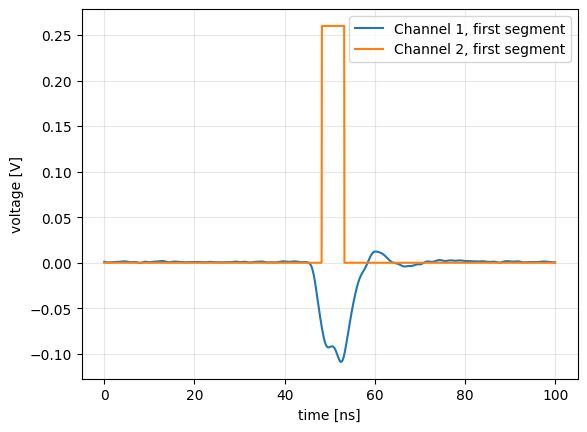

In [6]:
seg = 3 
plt.plot(ch1_time * 1e9, ch1_voltage[seg], label="Channel 1, first segment")
plt.plot(ch2_time * 1e9, ch2_voltage[seg], label="Channel 2, first segment")
plt.xlabel("time [ns]")
plt.ylabel("voltage [V]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Plot waveforms

For the PMT file, the time axis is in seconds and is often easier to view in nanoseconds.

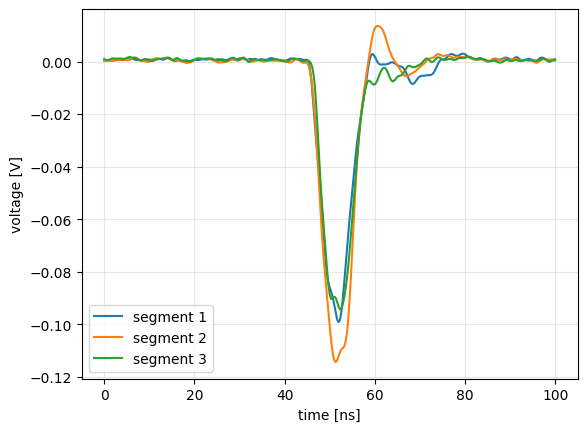

In [7]:
for row, segment in enumerate(metadata["segment_numbers"]):
    plt.plot(time * 1e9, voltage[row], label=f"segment {segment}")

plt.xlabel("time [ns]")
plt.ylabel("voltage [V]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Use absolute segment time

Use `time_axis="absolute"` when the segment time tag matters. In that mode the reader builds:

```python
time = SegmentedTimeTag + SegmentedXOrg + sample_index * XInc
```

In [8]:
absolute_time, absolute_voltage, absolute_metadata = read_keysight_h5(
    data_file,
    time_axis="absolute",
)

print("absolute time shape:", absolute_time.shape)
print("voltage shape:", absolute_voltage.shape)
print("segments:", absolute_metadata["segment_numbers"])
print("time tags:", absolute_metadata["time_tags"])


absolute time shape: (5, 1600)
voltage shape: (5, 1600)
segments: [1, 2, 3, 4, 5]
time tags: [0.         0.00194912 0.00389828 0.00584743 0.00779645]


## Read only segment time tags

If you only need timing between segments, `read_segment_time_tags` avoids loading the waveform arrays.

In [9]:
segments, time_tags = read_segment_time_tags(data_file)

print("number of segments:", len(segments))
print("first segment/tag:", segments[0], time_tags[0])
print("last segment/tag: ", segments[-1], time_tags[-1])

if len(time_tags) > 1:
    print("median spacing [s]:", np.median(np.diff(time_tags)))

number of segments: 5
first segment/tag: 1 0.0
last segment/tag:  5 0.0077964492468747615
median spacing [s]: 0.0019491364921875001
